In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
# Lendo os arquivos CSV
df_vns1 = pd.read_csv('VNS1.csv', sep=';')
df_vns2 = pd.read_csv('VNS2.csv', sep=';')

# Calculando e printando as médias
media_vns1 = df_vns1['FX'].mean()
media_vns2 = df_vns2['FX'].mean()

print(f"Média VNS1: {media_vns1:,.2f}")
print(f"Média VNS2: {media_vns2:,.2f}")

Média VNS1: 299,049,062.16
Média VNS2: 302,752,984.42


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19412\1082919483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='Algoritmo', y='FX', notch=True, palette='Set2')


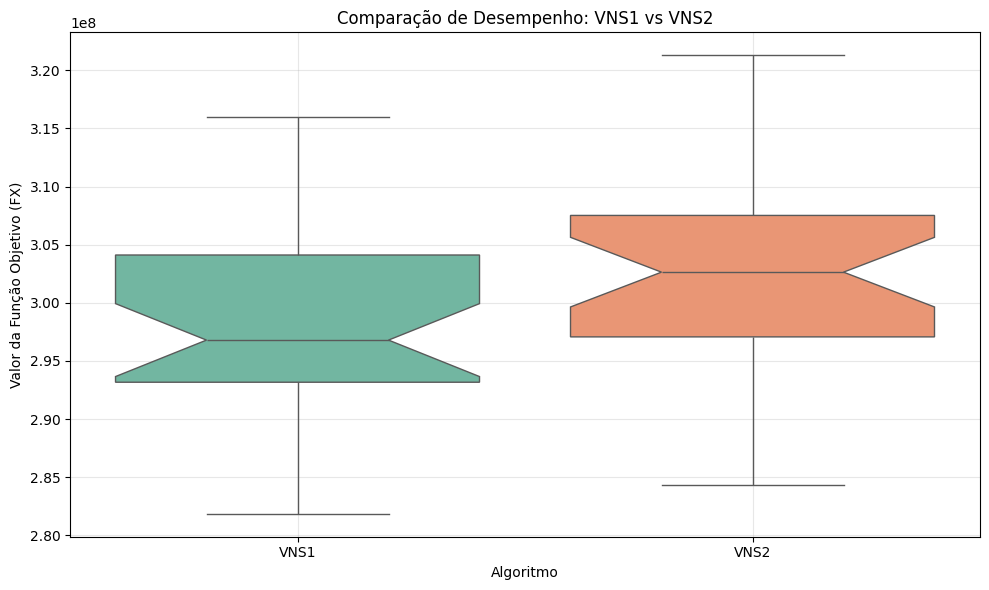

In [6]:
# Preparando dados para o boxplot
# Criando um DataFrame combinado
df_vns1['Algoritmo'] = 'VNS1'
df_vns2['Algoritmo'] = 'VNS2'
df_combined = pd.concat([df_vns1[['FX', 'Algoritmo']], df_vns2[['FX', 'Algoritmo']]], ignore_index=True)

# Criando o gráfico com boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='Algoritmo', y='FX', notch=True, palette='Set2')
plt.title('Comparação de Desempenho: VNS1 vs VNS2')
plt.ylabel('Valor da Função Objetivo (FX)')
plt.xlabel('Algoritmo')

# Formatando o eixo Y para melhor legibilidade
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adicionando grid para melhor visualização
plt.grid(True, alpha=0.3)

# Mostrando o gráfico
plt.tight_layout()
plt.show()

## testes estatísticos

The Shapiro–Wilk test is a statistical test used to check whether a dataset follows a normal distribution.

It tests the null hypothesis that the data are normally distributed. If the p-value is small (e.g., < 0.05), you reject normality.

In [ ]:
vns1 = df_vns1['FX']
vns2 = df_vns2['FX']

print(stats.shapiro(vns1))
print(stats.shapiro(vns2))

ShapiroResult(statistic=0.956744372844696, pvalue=0.2551786005496979)
ShapiroResult(statistic=0.9892010688781738, pvalue=0.9864834547042847)


ambos são normais

In [11]:
print(stats.ttest_ind(vns1, vns2, equal_var=False, alternative='greater'))

TtestResult(statistic=-1.8298464142144903, pvalue=0.9637859181607045, df=57.83645765155244)


A hipótese alternativa (H₁) é que a média de vns1 > média de vns2.

A hipótese nula (H₀) é que a média de vns1 ≤ média de vns2.

Como o p > 0.05, não rejeitamos H₀.

Em outras palavras: não há evidência estatística de que vns1 seja maior que vns2.

In [12]:
print(stats.ttest_ind(vns1, vns2, equal_var=False, alternative='less'))

TtestResult(statistic=-1.8298464142144903, pvalue=0.036214081839295496, df=57.83645765155244)


# Número de avaliações

In [13]:
# Calculando e printando as médias
media_vns1 = df_vns1['Evaluations'].mean()
media_vns2 = df_vns2['Evaluations'].mean()

print(f"Média VNS1: {media_vns1:,.2f}")
print(f"Média VNS2: {media_vns2:,.2f}")

Média VNS1: 25,327.50
Média VNS2: 25,228.23


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19412\1409859399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='Algoritmo', y='Evaluations', notch=True, palette='Set2')


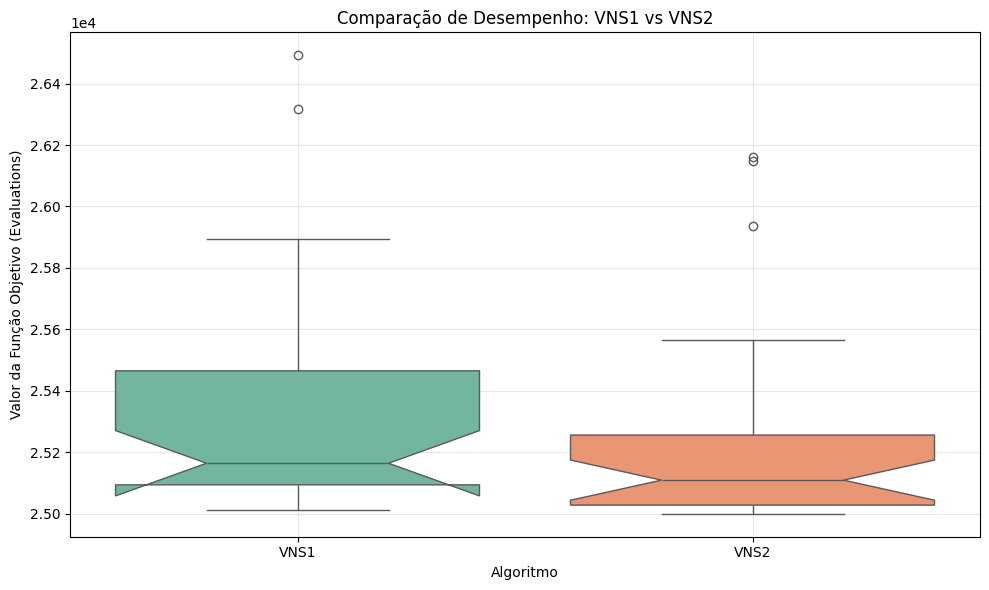

In [14]:
# Preparando dados para o boxplot
# Criando um DataFrame combinado
df_vns1['Algoritmo'] = 'VNS1'
df_vns2['Algoritmo'] = 'VNS2'
df_combined = pd.concat([df_vns1[['Evaluations', 'Algoritmo']], df_vns2[['Evaluations', 'Algoritmo']]], ignore_index=True)

# Criando o gráfico com boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='Algoritmo', y='Evaluations', notch=True, palette='Set2')
plt.title('Comparação de Desempenho: VNS1 vs VNS2')
plt.ylabel('Valor da Função Objetivo (Evaluations)')
plt.xlabel('Algoritmo')

# Formatando o eixo Y para melhor legibilidade
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adicionando grid para melhor visualização
plt.grid(True, alpha=0.3)

# Mostrando o gráfico
plt.tight_layout()
plt.show()

In [ ]:
vns1 = df_vns1['Evaluations']
vns2 = df_vns2['Evaluations']

print(stats.shapiro(vns1))
print(stats.shapiro(vns2))

# não são normais

ShapiroResult(statistic=0.7629875540733337, pvalue=1.48709168570349e-05)
ShapiroResult(statistic=0.6770633459091187, pvalue=7.357497224802501e-07)


In [17]:
print(stats.mannwhitneyu(vns1, vns2, alternative='greater'))
print(stats.mannwhitneyu(vns1, vns2, alternative='less'))

MannwhitneyuResult(statistic=562.0, pvalue=0.049612368020830765)
MannwhitneyuResult(statistic=562.0, pvalue=0.9518847669017123)


VNS1 consome mais avaliações da função objetivo que VNS2.

O p-value de 0.0496 está muito próximo do limiar de 0.05, então a significância é marginal.

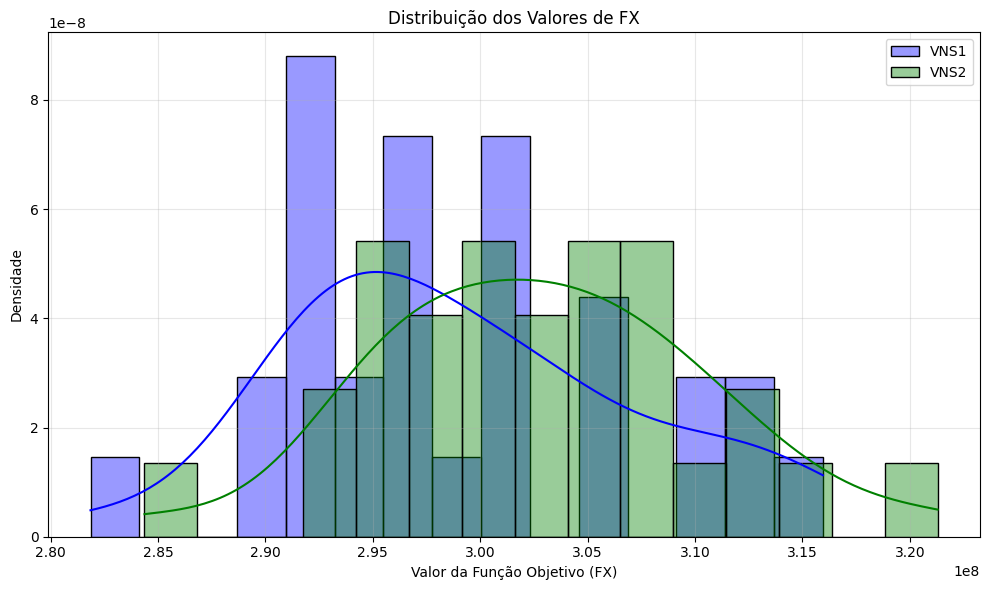

In [19]:
# %%
# Histograma + Curva de Densidade (Kernel Density Estimation - KDE)

plt.figure(figsize=(10, 6))

# Histograma + KDE para cada algoritmo
sns.histplot(df_vns1['FX'], color='blue', label='VNS1', kde=True, stat="density", alpha=0.4, bins=15)
sns.histplot(df_vns2['FX'], color='green', label='VNS2', kde=True, stat="density", alpha=0.4, bins=15)

plt.title('Distribuição dos Valores de FX')
plt.xlabel('Valor da Função Objetivo (FX)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


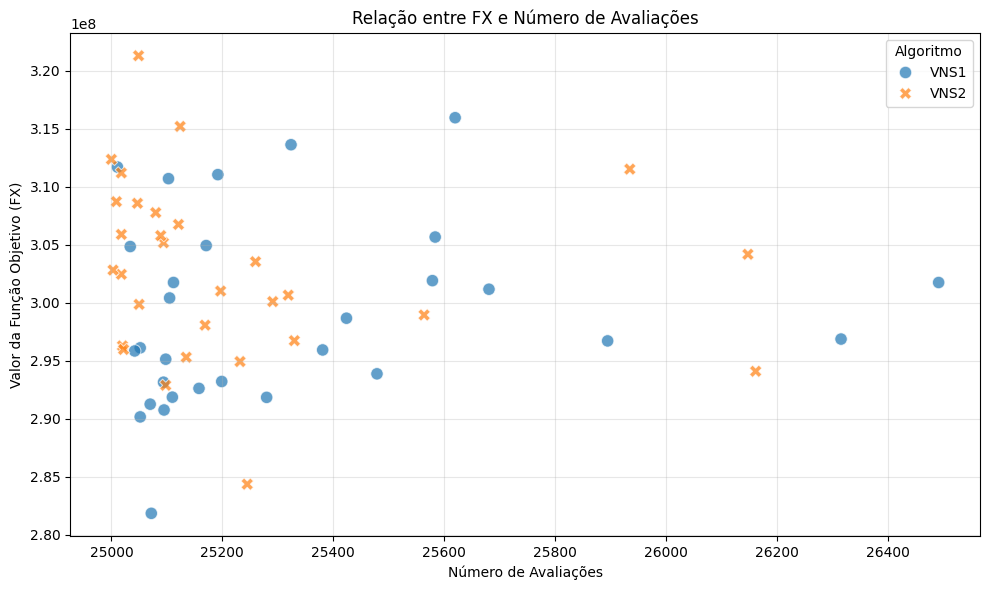

In [18]:
# Criando DataFrame combinado
df_vns1['Algoritmo'] = 'VNS1'
df_vns2['Algoritmo'] = 'VNS2'
df_scatter = pd.concat([df_vns1[['FX', 'Evaluations', 'Algoritmo']],
                        df_vns2[['FX', 'Evaluations', 'Algoritmo']]], ignore_index=True)

# Plotando gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, 
                x='Evaluations', 
                y='FX', 
                hue='Algoritmo', 
                style='Algoritmo',
                s=80, alpha=0.7)

plt.title('Relação entre FX e Número de Avaliações')
plt.xlabel('Número de Avaliações')
plt.ylabel('Valor da Função Objetivo (FX)')

# Ajustando escala do eixo Y, se os valores forem muito grandes
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()